In [1]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([
[3.0, 2.0, 1.0],
[4.0, 1.0, 2.0],
[1.0, 3.0, 2.0],
[2.0, 2.0, 4.0],
[5.0, 0.0, 1.0],
])

X.shape

(5, 3)

### **Questions:**
1. What do the rows and columns of 𝑋 represent? What does 𝑋4,2 represent in words?
2. What is the shape of 𝑋? What is the shape of 𝑋𝑣 if 𝑣 ∈ ℝ3?
3. Explain why centering or scaling columns might be useful before comparing observations or finding directions of variation.

### **Answers:**
1. Rows represent the individual vectors while columns represent the numbers in each position of the vector. Going down rows entails the traversal of different vectors while going across columns entails the traversal of the individual entries in a specific vector. X4,2 represents the number in the 4th row and 2nd column of X, which is associated with the second number in the fourth vector in the matrix X.
2. X is a 5 x 3 array. Xv would be 5 x 1 if v ∈ ℝ3.
3. Manipulating columns before comparing observations is important to maintain signal strength. Values across columns can vary in magnitude, and without scaling, columns with consistently large numbers would bury patterns in the columns with smaller magnitude numbers. Thus, centering and scaling allows each column to be compared with equal weight. 


### **Questions:**

Let x = [3, 2, 1] and y = [1, 1, 0]. Treat y as a reference pattern involving the first two features. 

1. Compute the projection
$\bm{x_2} = proj_{\bm{y}}(\bm{x}) = \frac {\bm{x}^T\bm{y}}{\bm{y}^T\bm y}$
2. Compute the residual x1 = x - x2.
3. Verify that $ \bm{x}_1^T \bm{y} = 0 $. What does this tell you geometrically?
4. What does x2 measure, and what information remains in x1?

### **Answers:**

1. x2 = [5/2, 5/2, 0].
2. x1 = x - x2 = [3, 2, 1] - [5/2, 5/2, 0] = [1/2, -1/2, 1].
3. $ \bm{x}_1^T \bm{y} = 0 $ --> 1/2 * 1 + -1/2 * 1 + 1 * 0 = 0. This tells us that x1 and y are perpendicular (i.e. they have no component in the same direction). 
4. x2 measures the component of x that is in the same direction as y. x1 contains the remaining portion of the vector, which is not in the direction of y. In other words, x1 is the vector difference between x and x2.


In [2]:
#Use X and reference direction y.

X = np.array([
[3.0, 2.0, 1.0],
[4.0, 1.0, 2.0],
[1.0, 3.0, 2.0],
[2.0, 2.0, 4.0],
[5.0, 0.0, 1.0],
])

y = np.array([1.0, 1.0, 0.0])

### **Questions:**

1. Compute the projection coefficient for each row of 𝑋. Store the results in a one-dimensional array.
2. Which observation is most aligned with y? Explain how you decided.
3. Plot the five projection coefficients with labeled axes and a descriptive title.
4. Explain why projection onto a direction can be useful for visualization or summarization.
5. The central dogma describes information flow from DNA to RNA to protein. Give one example
of how a vector of measurements could represent one of these biological objects, and explain your
thinking on if a projection score should be interpreted as an association with a pattern or as proof
of a causal mechanism.
6. In a single-cell RNA-sequencing matrix, what do rows and columns usually represent? Give one
reason cell-level normalization or gene filtering might be needed before computing projection scores.
7. Let b1 and b2 be two linearly independent reference directions. Explain the difference between their
span and a basis for that span. How could projecting onto several directions relate to the SVD $ X = U\Sigma V^T$?

Projection coefficient array: [2.5, 2.5, 2. , 2. , 2.5]
Angles array: [[19.10660535, 39.50971229, 40.89339465, 54.73561032, 46.10211375]]


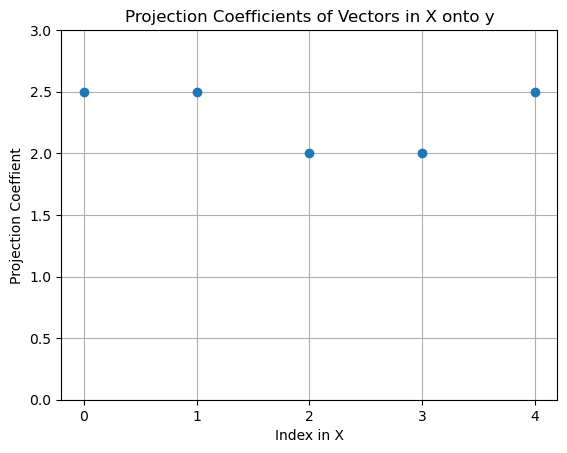

In [ ]:
### 
# ANSWERS
###

#1.
denom = np.dot(y, y)
v = np.dot(X, y)
proj_coef = v/denom
proj_coef_print = np.array2string(v/denom, separator=', ')
print(f"Projection coefficient array: {proj_coef_print}")

#2. 
# For each vector v in X, v * y = |x||y|cos(angle)

dotmatrix = X @ y.reshape(-1, 1)

X_mags = np.linalg.norm(X, axis=1, keepdims=True)

cos_angle = dotmatrix / (X_mags * np.linalg.norm(y))

angles_deg = np.array2string((np.degrees(np.arccos(cos_angle))).transpose(), separator=", ")

print(f"Angles array: {angles_deg}")

#The first vector [3.0, 2.0, 1.0] is the most aligned with y. This was determined by calculating the dot product of each vector in X with y, and then dividing those products by the product of the magnitudes to determine the cosine of the angle between them. This employed the property that the dot of vector v and vector y is equal to the product of the magnitudes times the cosine of the angle. Taking the inverse of this value yielded the angle. Since the angle of the 1st vector was closest to 0, it is the one most aligned with y.

#3. 
plt.plot(proj_coef, marker='o', linestyle='none', )
plt.xlabel('Index in X')
plt.xticks([0, 1, 2, 3, 4])
plt.ylabel('Projection Coeffient')
plt.yticks(np.arange(0, 3.5, 0.5))
plt.title('Projection Coefficients of Vectors in X onto y')
plt.grid(True)
plt.show()

#4
#Given some N-dimensional data, there could be a large amount of noise in the  measurements resulting in variation in all different directions. However, if a direction of significance is known from previous knowledge or a similar reason, then projecting the vectors containing the data onto a reference vector in this direction could help filter out the noise and focus on actual signal of importance. In addition, projection onto a direction carefully chosen to capture as much variance in the data as possible can allow for dimensionality reduction, which makes data easier to analyze and visualize while minimizing the information lost. In this way, insights in the data can be highlighted while removing some of the noise and complexity. 

#5
# A vector of measurements can be used to represent RNA counts in single-cell RNA sequencing data. Each element in the vector could represent the count of a different transcribed gene, so the measurements would contain information about the counts of RNA across many cells. A projection score could be calculated from these vectors to try and identify trends in how the number of copies of different RNAs vary with each other. Since data is simply observed from various different cells, any relationship found in the data cannot be attributed to anything in particular. In data science, correlation cannot be interpreted as causation since there could be a variety of other explanations for the relationship. Thus, the score should be interpreted as an association with a pattern instead of as proof of a causal mechanism.

#6
# In a single-cell RNA-sequencing matrix, rows usually representing individual cells while columns represent RNAs transcribed from a specific gene. Cell-level normalization might be required in order to account for biases present in data collection that could also affect bulk RNA counts. Some examples of these include variation in cell type, expression levels, cell size, and total instrument counts. By normalizing the information, RNA counts can be compared across invididuals and analyzed together. 

#7
#Their span is the set of all linear combinations of those two vectors. Since there are two linearly independent vectors, the span is a 2d space with infinite vectors. On the other hand, the basis for the span is any set of linearly indepedent reference directions in that space. B1 and b2 are two linearly independent vectors in that space, so they form a basis for the span. This also means that any set of vectors spanning that space will also only have two vectors.
###NEED TO ANSWER SVD PART

### **Questions**

Two observations have feature vectors 𝑎 = (1, 2, 1) and 𝑏 = (10, 20, 10).
1. What do you expect about their cosine similarity? Explain without calculating the exact value.
2. Would Euclidean distance and cosine similarity emphasize the same aspect of these observations?
Why or why not?
3. Give one biomedical situation in which direction matters more than magnitude, and one in which
magnitude is scientifically important

### **Answers**